In [3]:
# =========================================
# 1. IMPORTS & SETUP (Reproducibility)
# =========================================
import pandas as pd
import numpy as np
import random
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

import re
import string
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("FakeNewsNet.csv")

print("Initial Shape:", df.shape)

print("Dataset Details", df.head())

Initial Shape: (23196, 5)
Dataset Details                                                title  \
0  Kandi Burruss Explodes Over Rape Accusation on...   
1  People's Choice Awards 2018: The best red carp...   
2  Sophia Bush Sends Sweet Birthday Message to 'O...   
3  Colombian singer Maluma sparks rumours of inap...   
4  Gossip Girl 10 Years Later: How Upper East Sid...   

                                            news_url        source_domain  \
0  http://toofab.com/2017/05/08/real-housewives-a...           toofab.com   
1  https://www.today.com/style/see-people-s-choic...        www.today.com   
2  https://www.etonline.com/news/220806_sophia_bu...     www.etonline.com   
3  https://www.dailymail.co.uk/news/article-33655...  www.dailymail.co.uk   
4  https://www.zerchoo.com/entertainment/gossip-g...      www.zerchoo.com   

   tweet_num  real  
0         42     1  
1          0     1  
2         63     1  
3         20     1  
4         38     1  


In [5]:
# =========================================
# 3. DATA CLEANING
# =========================================
stop_words = set(stopwords.words('english'))

# Drop missing critical fields
df = df.dropna(subset=['title', 'real'])

# Remove duplicates
df = df.drop_duplicates(subset=['title'])

# Fill missing metadata
df['tweet_num'] = df['tweet_num'].fillna(0)
df['source_domain'] = df['source_domain'].fillna("unknown")

# -----------------------------------------
# TEXT CLEANING FUNCTION
# -----------------------------------------
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])

    return text

# Apply cleaning
df['clean_title'] = df['title'].apply(clean_text)

# Optional: remove very short texts (low information)
df = df[df['clean_title'].str.split().str.len() > 3]

# Target
y = df['real']

# Final check
print("Cleaned Data Shape:", df.shape)
print(df[['title', 'clean_title']].head())

Cleaned Data Shape: (20740, 6)
                                               title  \
0  Kandi Burruss Explodes Over Rape Accusation on...   
1  People's Choice Awards 2018: The best red carp...   
2  Sophia Bush Sends Sweet Birthday Message to 'O...   
3  Colombian singer Maluma sparks rumours of inap...   
4  Gossip Girl 10 Years Later: How Upper East Sid...   

                                         clean_title  
0  kandi burruss explodes rape accusation real ho...  
1        peoples choice awards best red carpet looks  
2  sophia bush sends sweet birthday message one t...  
3  colombian singer maluma sparks rumours inappro...  
4  gossip girl years later upper east siders shoc...  


In [6]:
# =========================================
# 4. TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=42
)

In [7]:
# =========================================
# 5. FEATURE ENGINEERING (TF-IDF + metadata)
# =========================================
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train['title'])
X_test_tfidf = tfidf.transform(X_test['title'])

# Add metadata feature (tweet_num)
X_train_meta = np.array(X_train['tweet_num']).reshape(-1, 1)
X_test_meta = np.array(X_test['tweet_num']).reshape(-1, 1)

# Combine features
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_meta])
X_test_combined = hstack([X_test_tfidf, X_test_meta])

In [8]:
# =========================================
# 6. BASELINE MODEL: LOGISTIC REGRESSION
# =========================================
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_combined, y_train)

lr_preds = lr_model.predict(X_test_combined)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# =========================================
# 7. RANDOM FOREST (ROBUST MODEL)
# =========================================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_combined, y_train)

rf_preds = rf_model.predict(X_test_combined)

In [10]:
# =========================================
# 8. TRANSFORMER MODEL (DISTILBERT)
# =========================================
from datasets import Dataset

print("Preparing Transformer Model...")

# Rename label column
X_train = X_train.rename(columns={"real": "label"})
X_test = X_test.rename(columns={"real": "label"})

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_function(example):
    return tokenizer(
        example['title'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_dataset = Dataset.from_pandas(X_train[['title', 'label']])
test_dataset = Dataset.from_pandas(X_test[['title', 'label']])

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    logging_dir='./logs'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

bert_preds = trainer.predict(test_dataset)
bert_preds = np.argmax(bert_preds.predictions, axis=1)

Preparing Transformer Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.367625,0.339105
2,0.248733,0.358043
3,0.134412,0.531749


In [11]:
# =========================================
# 9. EVALUATION FUNCTION
# =========================================
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{name} Performance:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return [name, acc, prec, rec, f1]

In [12]:
# =========================================
# 10. MODEL COMPARISON
# =========================================
results = []

results.append(evaluate_model("Logistic Regression", y_test, lr_preds))
results.append(evaluate_model("Random Forest", y_test, rf_preds))
results.append(evaluate_model("DistilBERT", y_test, bert_preds))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\nModel Comparison:\n", results_df)


Logistic Regression Performance:
Accuracy: 0.8349
Precision: 0.8416
Recall: 0.9631
F1 Score: 0.8983

Random Forest Performance:
Accuracy: 0.8568
Precision: 0.8637
Recall: 0.9627
F1 Score: 0.9105

DistilBERT Performance:
Accuracy: 0.8643
Precision: 0.8981
Recall: 0.9258
F1 Score: 0.9117

Model Comparison:
                  Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.834860   0.841637  0.963057  0.898262
1        Random Forest  0.856798   0.863714  0.962739  0.910542
2           DistilBERT  0.864272   0.898054  0.925796  0.911714


In [13]:
# =========================================
# 11. CONFUSION MATRIX (ROBUSTNESS)
# =========================================
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

[[ 439  569]
 [ 116 3024]]


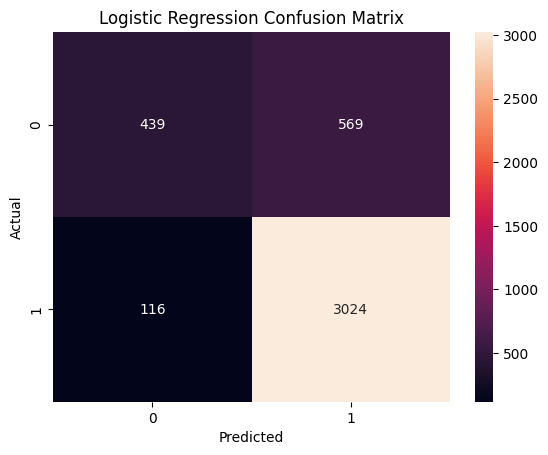

In [14]:
plot_confusion(y_test, lr_preds, "Logistic Regression Confusion Matrix")

[[ 531  477]
 [ 117 3023]]


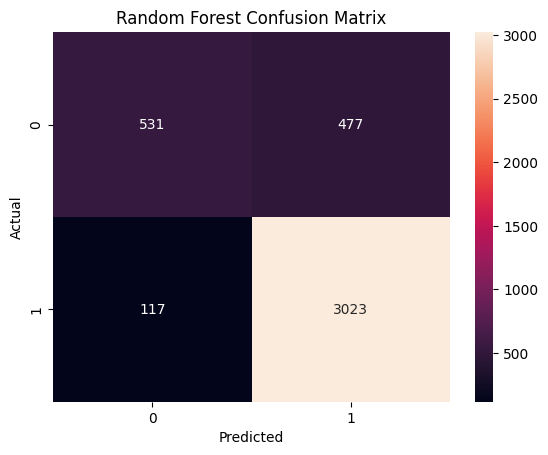

In [15]:
plot_confusion(y_test, rf_preds, "Random Forest Confusion Matrix")

[[ 678  330]
 [ 233 2907]]


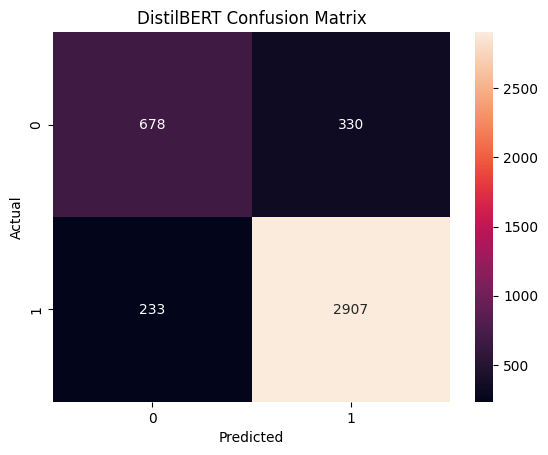

In [16]:
plot_confusion(y_test, bert_preds, "DistilBERT Confusion Matrix")